2-е Домашнее задание
EDA
ссылка на датасет:
https://www.kaggle.com/datasets/shebilmsp/youtube-trending-dataset-updated-daily?resource=download

In [5]:
import pandas as pd

#эта версия датасета актуальна на 09.03.2026
url = 'https://raw.githubusercontent.com/Rom4ik001p/ml-course-HW/refs/heads/main/hw02_EDA/trending_channels.csv'
df = pd.read_csv(url)

df.head()
#print('\n')
#df.tail()

,channel_id,title,description,published_at,thumbnails,custom_url,default_language,country,subscriber_count,video_count,view_count,banner_url,keywords,topics,made_for_kids,privacy_status
0,UCsPMNatXCwqyUuJilBT73jg,CaylusBlox,i play roblox here\nsubscribe and join the CAY...,2024-08-02T07:21:37.449899Z,https://yt3.ggpht.com/z9psGKSPOr0-ztINI6uA9JCd...,@caylusblox,NaN,US,7990000,658,2494114083,https://yt3.googleusercontent.com/U6gW0sfTCF5_...,"caylus caylusblox ""caylus roblox"" ""caylus mine...","Simulation_video_game, Role-playing_video_game...",False,public
1,UCh5mLn90vUaB1PbRRx_AiaA,MoreSidemen,Welcome to the Official Sidemen 2nd Channel wh...,2018-02-01T21:48:49Z,https://yt3.ggpht.com/ytc/AIdro_kg8VuO1devOCTB...,@moresidemen,NaN,GB,9480000,1407,5851408261,https://yt3.googleusercontent.com/ThqnxdcrOtaX...,sidemen moresidemen sdmn,"Action_game, Video_game_culture, Entertainment...",False,public
2,UC1sELGmy5jp5fQUugmuYlXQ,Minecraft,This is the official YouTube channel of Minecr...,2010-12-21T21:36:46Z,https://yt3.ggpht.com/scvGT8SucZvs5yIkBBFQ0s0I...,@minecraft,NaN,SE,18000000,1313,3051711943,https://yt3.googleusercontent.com/bO4nn2OO4rZV...,Minecraft Mojang MINECON Gaming Microsoft Game...,"Action_game, Role-playing_video_game, Video_ga...",False,public
3,UCX4W0HfIH-26SVU8PLYf7iw,NiZ Series,NiZ series (Not In Zip series) is where creati...,2025-11-16T01:41:13.983468Z,https://yt3.ggpht.com/CXpIGC-U17XSaj2DNrwiwqex...,@nizseries,NaN,IN,926,28,909120,https://yt3.googleusercontent.com/ay_3_CB84HB7...,"trending trailer ai tvk ""not in zip"" ""think di...","Entertainment, Film",False,public
4,UCKFnbjBQDzzh002TMJcyuZA,Saregama Kannada,Saregama India Limited - the one-stop destinat...,2012-06-21T12:40:19Z,https://yt3.ggpht.com/LbelUn06UQA3VfF-RP_cXeh-...,@saregamakannada,NaN,IN,1420000,2477,692576948,https://yt3.googleusercontent.com/kywgIfYJgF-k...,"""saregama kannada"" ""Kannada cinema"" Chandanava...","Film, Pop_music, Music, Music_of_Asia, Enterta...",False,public


In [6]:
print(df.shape)

(22399, 16)


In [7]:
print(df.info())
for i in range(60):(print('-',end=''))
print('')
print(df.describe())
for i in range(60):(print('-',end=''))
print('')
print(df.describe(include="object"))
for i in range(60):(print('-',end=''))
print('')
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22399 entries, 0 to 22398
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   channel_id        22399 non-null  object
 1   title             22399 non-null  object
 2   description       16885 non-null  object
 3   published_at      22399 non-null  object
 4   thumbnails        22399 non-null  object
 5   custom_url        18500 non-null  object
 6   default_language  1676 non-null   object
 7   country           15017 non-null  object
 8   subscriber_count  22399 non-null  int64 
 9   video_count       22399 non-null  int64 
 10  view_count        22399 non-null  int64 
 11  banner_url        20588 non-null  object
 12  keywords          12626 non-null  object
 13  topics            21700 non-null  object
 14  made_for_kids     22399 non-null  bool  
 15  privacy_status    22399 non-null  object
dtypes: bool(1), int64(3), object(12)
memory usage: 2.6+ MB
Non

In [8]:
#слишком много пропусков, удаляем столбец
cleared_df = df.drop('default_language', axis=1)

#слишком много нулей чтобы удалить эти строки,
#но слишком мало нулей чтобы избавиться от столбца
#заполним константой "undefined"
cleared_df['description'] = cleared_df['description'].fillna('No description')

#то же самое
cleared_df['keywords'] = cleared_df['keywords'].fillna("undefined")
cleared_df['custom_url'] = cleared_df['custom_url'].fillna('undefined')
cleared_df['banner_url'] = cleared_df['banner_url'].fillna('undefined')

#topics довольно важный столбик, но с учетом того что здесь около 3-4%
#пропусков, то можно строки с пропусками убрать
cleared_df.dropna(subset=['topics'], inplace=True)

#country можно заполнить модой для примера:
#country_mode = cleared_df['country'].mode()[0]
#cleared_df['country'] = cleared_df['country'].fillna(country_mode)
#однако по графику ниже можно сказать, что это не лучшая в нашем случае идея
#потому что страны распределены более менее равномерно и нет страны которая
#бы занимала большую часть записей, если мы заполним модой(США) пропуски, то
#модель будет думать что США имеет отрыв в десятки раз от остальных
#поэтому сделаем так:
cleared_df['country'] = cleared_df['country'].fillna("undefined")

#к сожелению нет числовых данных с пропусками, где mean бы использовалась для
#для заполнения сильно не отличавшихся значений
#и Медиана для более справедливого заполнения в случае если какие-то данные
#сильно отличаются

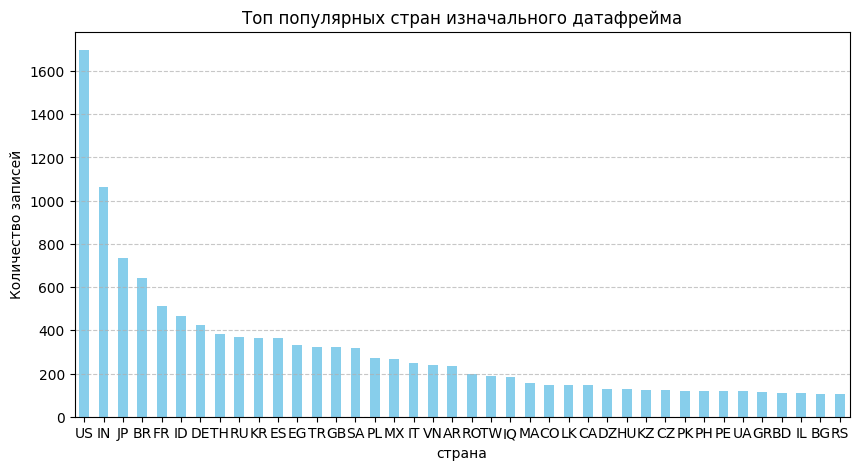

In [9]:
import matplotlib.pyplot as plt

# 1. Считаем частоту и берем, например, топ-20
top_countries = df['country'].value_counts().head(40)

# 2. Строим график
top_countries.plot(kind='bar', figsize=(10, 5), color='skyblue')
plt.title('Топ популярных стран изначального датафрейма')
plt.ylabel('Количество записей')
plt.xlabel('страна')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)
plt.show()


In [10]:
print('df:')
print(df.describe())
print('\nCleared df:')
print(cleared_df.describe())

print('\nVariance in old DF:')
print('   For subscriber_count: ' + str(df['subscriber_count'].var()))
print('   For video_count: ' + str(df['video_count'].var()))
print('   For view_count: ' + str(df['view_count'].var()))
print('Variance in cleared DF:')
print('   For subscriber_count: ' + str(cleared_df['subscriber_count'].var()))
print('   For video_count: ' + str(cleared_df['video_count'].var()))
print('   For view_count: ' + str(cleared_df['view_count'].var()))
#огромная дисперсия - нормальное явление для youtube, тк бывают максимально
#не популярные каналы и каналы миллионики - выбросы
print('\nSkewness in old DF:')
print('   For subscriber_count: ' + str(df['subscriber_count'].skew()))
print('   For video_count: ' + str(df['video_count'].skew()))
print('   For view_count: ' + str(df['view_count'].skew()))
print('Skewness in cleared DF:')
print('   For subscriber_count: ' + str(cleared_df['subscriber_count'].skew()))
print('   For video_count: ' + str(cleared_df['video_count'].skew()))
print('   For view_count: ' + str(cleared_df['view_count'].skew()))
#тк на ютубе большинство каналов не популярны и не залетевшие, а мизирное число
#ютуберов достигают успеха, то огромная положительная ассиметрия здесь справедлива
print('\nKurtosis in old DF:')
print('   For subscriber_count: ' + str(df['subscriber_count'].kurt()))
print('   For video_count: ' + str(df['video_count'].kurt()))
print('   For view_count: ' + str(df['view_count'].kurt()))
print('Kurtosis in cleared DF:')
print('   For subscriber_count: ' + str(cleared_df['subscriber_count'].kurt()))
print('   For video_count: ' + str(cleared_df['video_count'].kurt()))
print('   For view_count: ' + str(cleared_df['view_count'].kurt()))
#огромное значение эксцесса значит большая часть каналов имеют одинаковый успех
#обычно это не популярные каналы, потому что опять же те еденицы что составляют
#хвосты графика эксцесса это успешные каналы

df:
       subscriber_count    video_count    view_count
count      2.239900e+04   22399.000000  2.239900e+04
mean       9.661532e+05    1089.206170  5.294525e+08
std        4.408477e+06   10231.372439  3.591115e+09
min        0.000000e+00       0.000000  0.000000e+00
25%        1.180000e+04      43.000000  6.124132e+06
50%        1.100000e+05     152.000000  4.848481e+07
75%        5.460000e+05     627.000000  2.517494e+08
max        3.090000e+08  564114.000000  3.257473e+11

Cleared df:
       subscriber_count    video_count    view_count
count      2.170000e+04   21700.000000  2.170000e+04
mean       9.966086e+05    1093.070599  5.457973e+08
std        4.475535e+06    9727.639406  3.647017e+09
min        0.000000e+00       0.000000  0.000000e+00
25%        1.510000e+04      48.000000  7.758889e+06
50%        1.200000e+05     162.500000  5.345403e+07
75%        5.740000e+05     655.000000  2.664100e+08
max        3.090000e+08  564114.000000  3.257473e+11

Variance in old DF:
   For s

In [11]:
#pip install category_encoders

In [12]:
#я решил посчитать кол-во уникальных слов, а не списков слов в keywords и topics
#чтобы убедиться какое оптимальное n_features взять в дальнейшем для feature encoding
#согласно gemini береться число около log2(count), но лучше проверять по работе модели
unique_keywords_count = cleared_df['keywords'].str.replace(',', ' ').str.split().explode().nunique()
print(unique_keywords_count)
unique_topic_words_count = cleared_df['topics'].str.replace(',', ' ').str.split().explode().nunique()
print(unique_topic_words_count)


118636
60


In [13]:
#так как в keywords много уникальных слов посчитаем
#сколько в среднем приходиться слов на строку в таблице

# Разбиваем строку на слова и считаем длину получившегося списка для каждой строки
words_per_row = cleared_df['keywords'].str.replace(',', ' ').str.split().str.len()

avg_words = words_per_row.mean()
max_words = words_per_row.max()

print(f"В среднем слов в строке: {avg_words:.2f}")
print(f"Максимум слов в одной строке: {max_words}")

В среднем слов в строке: 16.15
Максимум слов в одной строке: 102


In [14]:
pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 2.3 MB/s eta 0:00:00


In [15]:
#пришло время к кодированию, хэшированию и созданием новых фич
#удаляем столбцы: privacy_status(везде одинаковое значение), айди и ссылки
#(channel_id, custom_url, thumbnails, banner_url), описания и заголовки (title,
#description)
cleared_df = cleared_df.drop('privacy_status', axis=1)
cleared_df = cleared_df.drop('channel_id', axis=1)
cleared_df = cleared_df.drop('custom_url', axis=1)
cleared_df = cleared_df.drop('thumbnails', axis=1)
cleared_df = cleared_df.drop('banner_url', axis=1)
cleared_df = cleared_df.drop('title', axis=1)
cleared_df = cleared_df.drop('description', axis=1)

#применим OneHot кодирование к колонке made for kids
cleared_df = pd.get_dummies(cleared_df, columns=['made_for_kids'], drop_first=True)

#применим target encoding к country, так как там много значений как для onehot,
#и мы можем связать эту колонку с view_count
import category_encoders as ce

# 1. Создаем объект кодировщика
encoder = ce.TargetEncoder(cols=['country'])
# 2. Обучаем и трансформируем
cleared_df['country_encoded'] = encoder.fit_transform(cleared_df['country'], cleared_df['view_count'])

#будем применять feature hashing  к topics и keywords т.к. там много уникальных признаков
#используя любимую нейронку(gemini) пишшем и анализируем код:
from sklearn.feature_extraction import FeatureHasher
import pandas as pd

# 1. Подготовка данных: превращаем строки в списки слов
# Если данные разделены запятыми или пробелами, используем split()
def to_list(x):
    return str(x).replace(',', ' ').split()

cleared_df['topics_list'] = cleared_df['topics'].apply(to_list)
cleared_df['keywords_list'] = cleared_df['keywords'].apply(to_list)

# 2. Настраиваем хэширование для Topics
# n_features=10 означает, что вместо колонки topics появится 10 новых колонок
hasher_topics = FeatureHasher(n_features=10, input_type='string')
hashed_topics = hasher_topics.transform(cleared_df['topics_list']).toarray()
df_topics_hashed = pd.DataFrame(hashed_topics, columns=[f'topic_h{i}' for i in range(10)])

# 3. Настраиваем хэширование для Keywords
# Для ключевиков следовало бы взять чуть ли не сотню колонок т.к. в среднем
#слов на запись в таблице около 16 и максимум было 102
#но проконсультировавшись с gemini мы сделали вывод что 30 колонок хватит
#да будет шум, но так модель хотя бы увидит общие тенденции, тем более это дз
hasher_keys = FeatureHasher(n_features=30, input_type='string')
hashed_keys = hasher_keys.transform(cleared_df['keywords_list']).toarray()
df_keys_hashed = pd.DataFrame(hashed_keys, columns=[f'key_h{i}' for i in range(30)])

# 4. Соединяем с основным датафреймом и удаляем старые колонки
cleared_df = pd.concat([cleared_df.reset_index(drop=True), df_topics_hashed, df_keys_hashed], axis=1)
cleared_df.drop(['keywords', 'topics_list', 'keywords_list'], axis=1, inplace=True)

In [16]:
#давайте добавим пару новых фич
#столбик published_at идеально подходит чтобы вычленить год/месяц/день публикации ролика
#для создания новых признаков

# 1. Переводим в правильный формат даты Pandas
# Исправленный вариант
cleared_df['published_at'] = pd.to_datetime(cleared_df['published_at'], format='ISO8601')

# 2. Создаем признак "Возраст видео" (в днях)
# Берем текущую дату в формате UTC (так как в данных есть Z - Zulu time)
now = pd.Timestamp.now(tz='UTC')
cleared_df['video_age_days'] = (now - cleared_df['published_at']).dt.days

# 3. Создаем признак "День недели" (от 0 до 6, где 0 - понедельник)
# Поможет модели понять, влияет ли день публикации на успех
cleared_df['publish_day_of_week'] = cleared_df['published_at'].dt.dayofweek

# 4. Создаем признак "Месяц" (от 1 до 12)
# Поможет поймать сезонность (например, декабрь - пик рекламы и просмотров)
cleared_df['publish_month'] = cleared_df['published_at'].dt.month

# Теперь оригинальную колонку с датой можно удалять
cleared_df.drop('published_at', axis=1, inplace=True)

In [17]:
print(cleared_df.info())
for i in range(60):(print('-',end=''))
print('')
print(cleared_df.describe())
for i in range(60):(print('-',end=''))
print('')
print(cleared_df.describe(include="object"))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21700 entries, 0 to 21699
Data columns (total 50 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   country              21700 non-null  object 
 1   subscriber_count     21700 non-null  int64  
 2   video_count          21700 non-null  int64  
 3   view_count           21700 non-null  int64  
 4   topics               21700 non-null  object 
 5   made_for_kids_True   21700 non-null  bool   
 6   country_encoded      21700 non-null  float64
 7   topic_h0             21700 non-null  float64
 8   topic_h1             21700 non-null  float64
 9   topic_h2             21700 non-null  float64
 10  topic_h3             21700 non-null  float64
 11  topic_h4             21700 non-null  float64
 12  topic_h5             21700 non-null  float64
 13  topic_h6             21700 non-null  float64
 14  topic_h7             21700 non-null  float64
 15  topic_h8             21700 non-null 

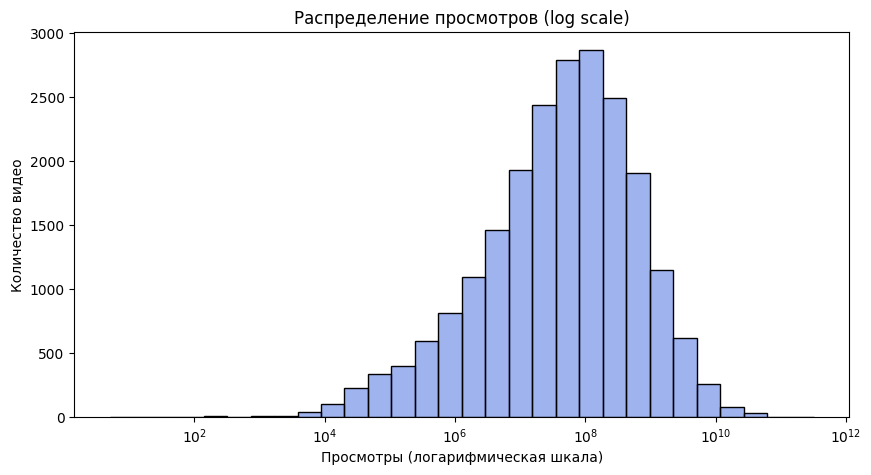

In [18]:
import seaborn as sns

# Установим стиль
sns.reset_defaults()

plt.figure(figsize=(10, 5))
# Используем логарифмическую шкалу для X, иначе увидим одну палку у нуля
sns.histplot(cleared_df['view_count'], kde=True, bins = 30, log_scale=True, color='royalblue')
plt.title('Распределение просмотров (log scale)')
plt.xlabel('Просмотры (логарифмическая шкала)')
plt.ylabel('Количество видео')
plt.show()

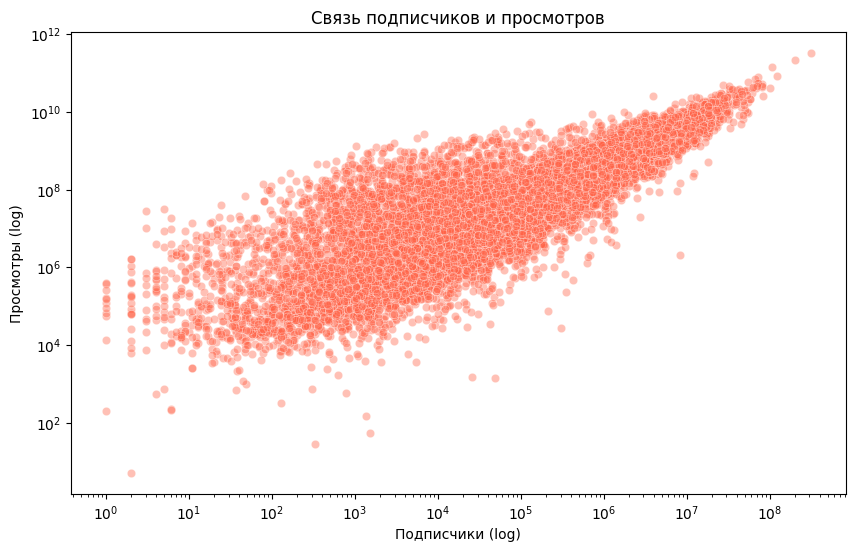

In [19]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=cleared_df, x='subscriber_count', y='view_count', alpha=0.4, color='tomato')
plt.xscale('log')
plt.yscale('log')
plt.title('Связь подписчиков и просмотров')
plt.xlabel('Подписчики (log)')
plt.ylabel('Просмотры (log)')
plt.show()

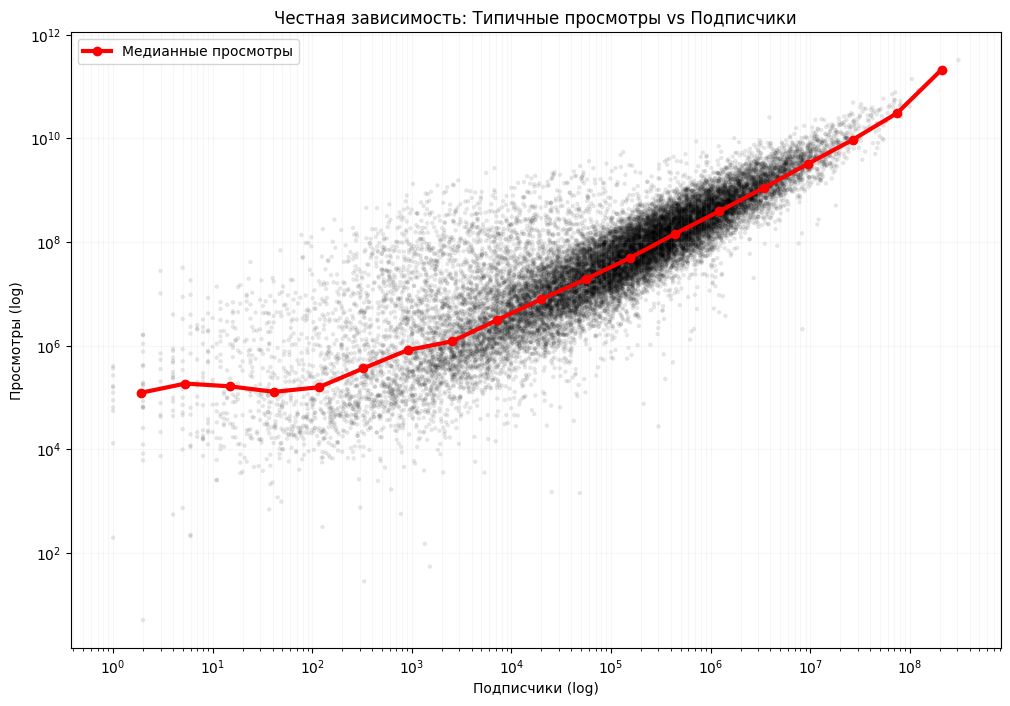

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Создаем логарифмические корзины для подписчиков
# Это разобьет весь диапазон на 20 участков, которые визуально равны
bins = np.logspace(np.log10(cleared_df['subscriber_count'].min() + 1),
                   np.log10(cleared_df['subscriber_count'].max()), 20)

# 2. Группируем данные и считаем медиану (она устойчива к выбросам)
cleared_df['sub_bin'] = pd.cut(cleared_df['subscriber_count'], bins=bins)
median_stats = cleared_df.groupby('sub_bin', observed=True)['view_count'].median().reset_index()

# Получаем центральные точки для каждой корзины для отрисовки
median_stats['sub_center'] = median_stats['sub_bin'].apply(lambda x: x.mid)

# 3. Визуализация
plt.figure(figsize=(12, 8))

# Фоновые точки
sns.scatterplot(data=cleared_df, x='subscriber_count', y='view_count',
                alpha=0.1, s=10, color='black', edgecolors='none')

# Честная медианная кривая
plt.plot(median_stats['sub_center'], median_stats['view_count'], color='red', linewidth=3, marker='o', label='Медианные просмотры')

plt.xscale('log')
plt.yscale('log')
plt.grid(True, which="both", ls="-", alpha=0.1)
plt.title('Связь подписчиков и просмотров с медианной кривой')
plt.xlabel('Подписчики (log)')
plt.ylabel('Просмотры (log)')
plt.legend()
plt.show()

/tmp/ipykernel_314/2789470001.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=day_popularity, x='publish_day_of_week', y='view_count', palette='viridis')


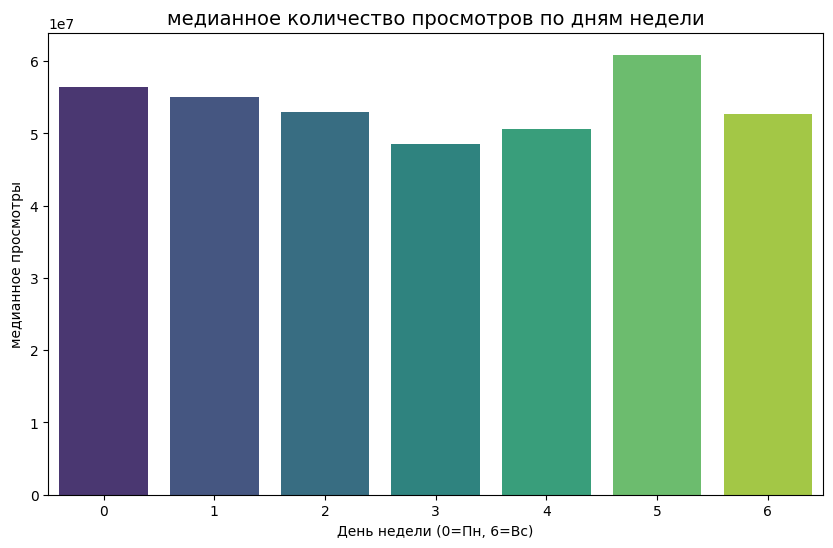

In [26]:
# Считаем медианное кол-во просмотров для каждого дня
day_popularity = cleared_df.groupby('publish_day_of_week')['view_count'].median().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=day_popularity, x='publish_day_of_week', y='view_count', palette='viridis')

plt.title('медианное количество просмотров по дням недели', fontsize=14)
plt.xlabel('День недели (0=Пн, 6=Вс)')
plt.ylabel('медианное просмотры')
plt.show()

/tmp/ipykernel_314/1544988724.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=topic_stats.head(30),


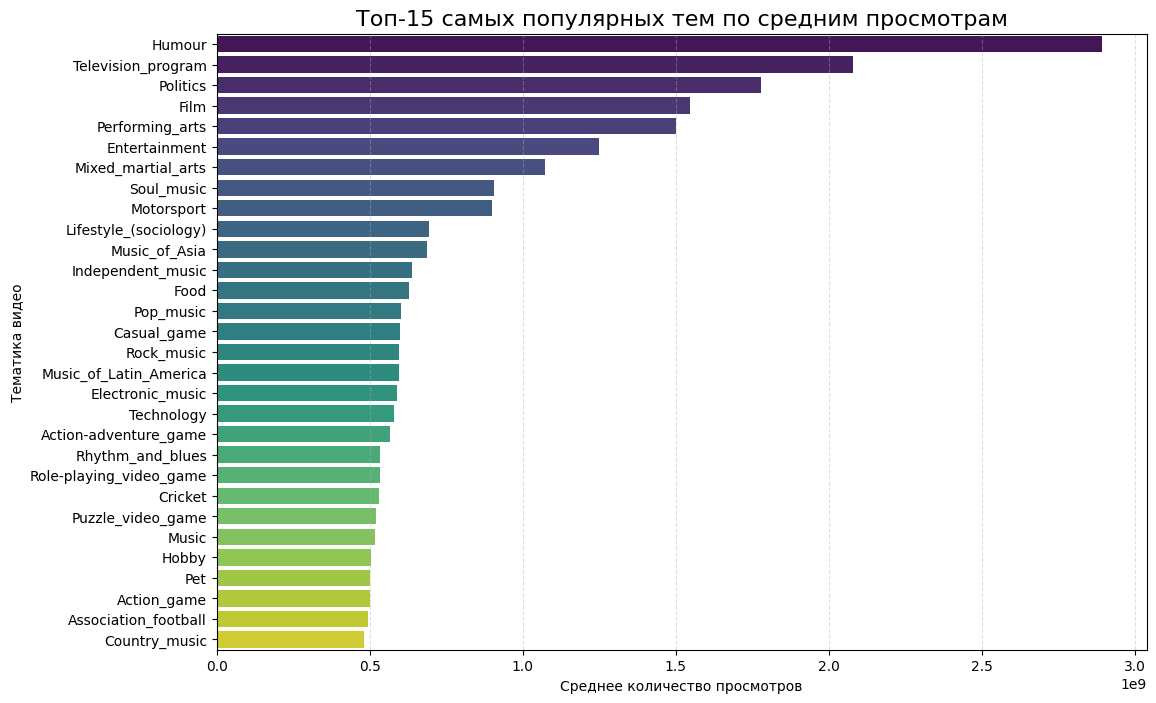

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Если темы записаны строкой "Music, Entertainment", превращаем их в список
if cleared_df['topics'].dtype == 'O':
    # Очищаем от лишних символов (скобки, кавычки) и разбиваем по запятой
    temp_df = cleared_df.copy()
    temp_df['topics'] = temp_df['topics'].str.replace(r"[\[\]']", "", regex=True).str.split(", ")
else:
    temp_df = cleared_df.copy()

# 2. "Взрываем" список: одна тема — одна строка
exploded_df = temp_df.explode('topics')

# 3. Считаем средние просмотры для каждой темы
topic_stats = exploded_df.groupby('topics')['view_count'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 8))

# Берем топ-30 тем
sns.barplot(data=topic_stats.head(30),
            x='view_count',
            y='topics',
            palette='viridis')

plt.title('Топ-30 самых популярных тем по средним просмотрам', fontsize=16)
plt.xlabel('Среднее количество просмотров')
plt.ylabel('Тематика видео')
plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.show()

/tmp/ipykernel_314/3077264564.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='made_for_kids_True', y='video_count', data=cleared_df, palette='Pastel1')


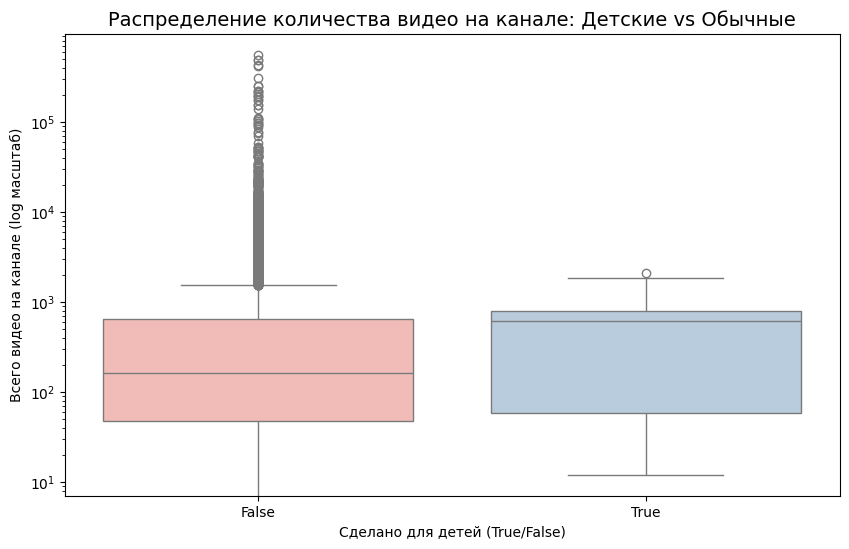

In [24]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='made_for_kids_True', y='video_count', data=cleared_df, palette='Pastel1')

# Используем логарифм, так как есть каналы с 10 видео, а есть с 100 000
plt.yscale('log')
plt.title('Распределение количества видео на канале: Детские vs Обычные', fontsize=14)
plt.xlabel('Сделано для детей (True/False)')
plt.ylabel('Всего видео на канале (log масштаб)')
plt.show()

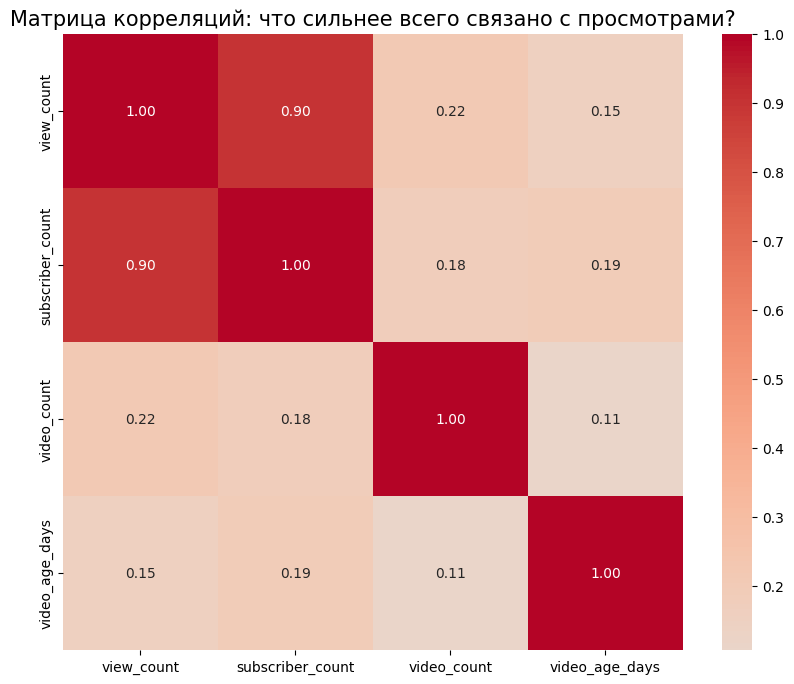

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# Выбираем ключевые метрики, чтобы не загромождать график
# Включаем просмотры, сабов, количество видео, возраст и пару хэшей
selected_metrics = ['view_count', 'subscriber_count', 'video_count', 'video_age_days']
# Добавим топ-темы из твоего предыдущего анализа, если они в числовом виде
# corr_matrix = cleared_df[selected_metrics].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(cleared_df[selected_metrics].corr(),
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            center=0)

plt.title('Матрица корреляций: что сильнее всего связано с просмотрами?', fontsize=15)
plt.show()

Что я понял про датасет:
1. до 5 тысяч подписчиков кол-во просмотров которые вы собираете почти никак не зависят от того сколько у вас подписчиков, однако после 5к сабов функция среднего увеличения просмотров от числа подписчиков растет линейно
2. наибольшим образом с кол-вом просмотров коррелирует кол-во подписчиков
3. на удивление корреляция между возрастом видео и кол-вом просмотров очень небольшая, всего 0.15
4. медианное значение кол-ва видео на канале у авторов чья аудитория взрослая примерно в 3 раза меньше (180+-) чем у тех у кого детская аудитория (600+-)
5. При этом выбросов среди кол-ва видео на каналах с детской аудиторией практически отстутствуют и максимальный выброс равен 2000+- кол-ва видео
6. Зато у каналов с взрослой аудиторией огромное-кол-во выбросов от 1,5 тыс видео до около 700 тыс видео
7. Как не странно Топ 3 темы видео: Юмор и комедии, ТВ программы, политика
8. Учитывая медианное кол-во просмотров по дням недели, видно, что видео опубликованные в субботу собирают больше просмотров, предположительно потому что на выходных больше времени есть позалипать в ютуб

С помощью использования Gemini я узнал:
  *в каких случаях и как заполнять пропуски
  *Что такое эксцесс, дисперсия и ассиметрия и как ее находить
  *Какие есть виды кодирования, какой их принцип работы и когда имеет смысл использовать определенный вид
Также Gemini помог мне написать код, для разных пунктов задания, а также пояснял и подсказывал какие данные нам целесообразно кодировать, создать(feature engineering), и что мы можем узнать с помощью  разных методов визуализации